In [1]:
import os
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import resample

In [3]:
patients_train = [
    '101', '102', '104', '105', '106', '107', '108', '109', '112', '113', 
    '114', '115', '116', '117', '118', '121', '122', '123', '200', '201', 
    '202', '205', '207', '208', '209', '210', '212', '213', '214', '215', 
    '219', '220', '221', '223', '228', '230', '231', '232', '234'
]

patients_test = [
    '100', '103', '111', '119', '124', '203', '217', '222', '233'
]

# Fusionamos la clase 3 (F) con la clase 2 (V)
También pasamos la clase 4 a la 3

In [5]:
db_dir = "../data/mitdb_data"

def beats_extraction(patient_list, dir_path=db_dir, window_size=1500):
    X_signals = []
    X_rr_features = []
    y_labels = []
    
    aami_mapping = {'N':0, 'L':0, 'R':0, 'e':0, 'j':0, 
                    'A':1, 'a':1, 'J':1, 'S':1, 
                    'V':2, 'E':2, 'F':2, '/':3, 'f':3, 'Q':3}
    
    fs_target = 500  
    half_w = window_size // 2

    for patient in patient_list:
        record_path = os.path.join(dir_path, patient)
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')
        
        num_samples = int(len(record.p_signal) * fs_target / record.fs)
        signals_resampled = resample(record.p_signal, num_samples)
        
        resample_factor = fs_target / record.fs
        peaks_resampled = np.array([int(p * resample_factor) for p in annotation.sample])
        symbols = annotation.symbol
        rr_intervals = np.diff(peaks_resampled)
        
        for i in range(1, len(peaks_resampled) - 1):
            sym = symbols[i]
            if sym not in aami_mapping:
                continue
                
            idx = peaks_resampled[i]
            if idx - half_w < 0 or idx + half_w > len(signals_resampled):
                continue
                
            beat_signal = signals_resampled[idx - half_w : idx + half_w, :]
            
            rr_previo = rr_intervals[i-1]
            rr_siguiente = rr_intervals[i]
            
            start_history = max(0, i-8)
            rr_local_mean = np.mean(rr_intervals[start_history:i]) + 1e-8
            
            # Ratios relativos locales
            rr_previo_rel = rr_previo / rr_local_mean
            rr_siguiente_rel = rr_siguiente / rr_local_mean
            rr_ratio_global = rr_previo / (rr_siguiente + 1e-8)
            rr_diff_transicion = rr_siguiente_rel - rr_previo_rel
            
            X_signals.append(beat_signal)
            # Mantenemos las 4 dimensiones pasando la nueva feature explícita
            X_rr_features.append([rr_previo_rel, rr_siguiente_rel, rr_diff_transicion, rr_ratio_global])
            y_labels.append(aami_mapping[sym])
            
    return np.array(X_signals), np.array(X_rr_features), np.array(y_labels)

all_patients = patients_train + patients_test
X_all_sig, X_all_rr, y_all = beats_extraction(all_patients)


In [6]:
def normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std, mean, std

X_all_sig_norm, _, _ = normalize(X_all_sig)

In [7]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

n_samples, timesteps, channels = X_all_sig_norm.shape
X_all_sig_flat = X_all_sig_norm.reshape(n_samples, timesteps * channels)

# Hacemos el Split Aleatorio por Latidos (La madre de todas las fugas de datos)
indices_all = np.arange(n_samples)
idx_train, idx_test = train_test_split(indices_all, test_size=0.2, random_state=42, stratify=y_all)

X_train_sig_pre = X_all_sig_flat[idx_train]
X_train_rr_pre  = X_all_rr[idx_train]
y_train_pre     = y_all[idx_train]

# El bloque de TEST se queda congelado aquí (pero ya contaminado con fisonomías de Train)
X_test_sig_intra = X_all_sig_norm[idx_test]
X_test_rr_intra  = X_all_rr[idx_test]
y_test_intra     = y_all[idx_test]

In [8]:
# %%
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

print("Aplicando RUS de N y SMOTE de las minoritarias en el set mezclado...")

# Concatenamos la señal aplanada y las 4 características RR en un solo vector por latido
X_train_combined = np.concatenate([X_train_sig_pre, X_train_rr_pre], axis=1)

# Bajamos la clase Normal (0) a 20,000 muestras con RUS
rus_intra = RandomUnderSampler(sampling_strategy={0: 20000}, random_state=42)
X_rus, y_rus = rus_intra.fit_resample(X_train_combined, y_train_pre)

strategy_smote = {1: 20000, 2: 20000, 3: 20000}

smote_intra = SMOTE(sampling_strategy=strategy_smote, random_state=42)
X_res_final, y_train_final_intra = smote_intra.fit_resample(X_rus, y_rus)

X_train_sig_flat_final = X_res_final[:, :3000]
X_train_rr_final_intra  = X_res_final[:, 3000:]

# Reconstruimos las dimensiones 3D de la señal para la capa Conv1D
X_train_sig_final_intra = X_train_sig_flat_final.reshape(-1, timesteps, channels)

print("\n" + "="*60)
print("DATASET INFLADO CON RUS + SMOTE TOTALMENTE BALANCED (4 CLASES IGUALES)")
print("="*60)
print(f"Distribución final de clases en Train: {np.bincount(y_train_final_intra)}")
print(f"Dimensiones finales de Señal en Train: {X_train_sig_final_intra.shape}")
print(f"Dimensiones finales de Rama RR en Train: {X_train_rr_final_intra.shape}")

Aplicando RUS de N y SMOTE de las minoritarias en el set mezclado...

DATASET INFLADO CON RUS + SMOTE TOTALMENTE BALANCED (4 CLASES IGUALES)
Distribución final de clases en Train: [20000 20000 20000 20000]
Dimensiones finales de Señal en Train: (80000, 1500, 2)
Dimensiones finales de Rama RR en Train: (80000, 4)


In [9]:
# %%
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

y_train_onehot_intra = to_categorical(y_train_final_intra, num_classes=4)
y_test_onehot_intra  = to_categorical(y_test_intra, num_classes=4)

# Escalamos la rama RR con las nuevas muestras sintéticas generadas por SMOTE
scaler_intra = StandardScaler()
X_train_rr_final_norm_intra = scaler_intra.fit_transform(X_train_rr_final_intra)
X_test_rr_final_norm_intra  = scaler_intra.transform(X_test_rr_intra)

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D,
                                     Conv1DTranspose, Input, Bidirectional, concatenate, BatchNormalization, Dropout,
                                     SpatialDropout1D, GlobalAveragePooling1D, Reshape, multiply, GlobalMaxPooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

In [11]:
def build_multimodal_network(window_size=1500, num_channels=2, rr_features_dim=4, output_classes=4):
    signal_input = Input(shape=(window_size, num_channels))

    conv_low = Conv1D(filters=16, kernel_size=5, padding="same", activation="relu")(signal_input)
    conv_mid = Conv1D(filters=16, kernel_size=15, padding="same", activation="relu")(signal_input)
    conv_high = Conv1D(filters=16, kernel_size=40, padding="same", activation="relu")(signal_input)
    conv_layer = concatenate([conv_low, conv_mid, conv_high])

    se_squeeze = GlobalAveragePooling1D()(conv_layer)
    se_ex1  = Dense(12, activation='relu', use_bias=False)(se_squeeze)
    se_ex2  = Dense(48, activation='sigmoid', use_bias=False)(se_ex1)
    se_scale = Reshape((1, 48))(se_ex2)
    conv_attended = multiply([conv_layer, se_scale])
    norm_1 = BatchNormalization()(conv_attended)

    lstm_1 = Bidirectional(LSTM(64, return_sequences=True))(norm_1)
    dropout_1 = SpatialDropout1D(0.3)(lstm_1)

    lstm_2 = Bidirectional(LSTM(32, return_sequences=True))(dropout_1)
    dropout_2 = SpatialDropout1D(0.3)(lstm_2)

    avg_pool = GlobalAveragePooling1D()(dropout_2)
    max_pool = GlobalMaxPooling1D()(dropout_2)
    signal_features = concatenate([avg_pool, max_pool])

    rr_input = Input(shape=(rr_features_dim,))
    rr_dense1 = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(rr_input)
    rr_norm1 = BatchNormalization()(rr_dense1)
    rr_dense2 = Dense(16, activation="relu")(rr_norm1)
    rr_features = BatchNormalization()(rr_dense2)

    rr_combined = concatenate([signal_features, rr_features])
    combined_norm = BatchNormalization()(rr_combined)

    dense_1 = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(combined_norm)
    dropout_3 = Dropout(0.4)(dense_1)
    dense_2 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(dropout_3)
    output_layer = Dense(output_classes, activation='softmax')(dense_2)

    return Model(inputs=[signal_input, rr_input], outputs=output_layer)

model_fake = build_multimodal_network(output_classes=4)
model_fake.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1500, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1500, 16)  │        176 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1500, 16)  │        496 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1500, 16)  │      1,296 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1500, 48)  │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ concatenate[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 12)        │        576 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 48)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 48)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1500, 48)  │          0 │ concatenate[0][0… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1500, 48)  │        192 │ multiply[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1500, 128) │     57,856 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 1500, 128) │          0 │ bidirectional[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 1500, 64)  │     41,216 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        160 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 1500, 64)  │          0 │ bidirectional_1[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ spatial_dropout1

 Total params: 115,332 (450.52 KB)

 Trainable params: 114,852 (448.64 KB)

 Non-trainable params: 480 (1.88 KB)

Incluimos Poly focal loss.

Y ahora hacemos los alpha_weights.

Ahora ya podemos entrenar el modelo binario

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

checkpoint_fake = ModelCheckpoint(
    monitor="val_f1_macro",
    filepath="../models/classificator_v1_fake_SMOTE_RUS.keras",
    save_best_only=True,
    verbose=1,
    mode="max"
)

early_stopping = EarlyStopping(monitor="val_f1_macro", patience=6, restore_best_weights=True, verbose=1, mode="max")
reduce_lr = ReduceLROnPlateau(monitor="val_f1_macro", patience=2, factor=0.5, min_lr=1e-8, verbose=1, mode="max")

model_fake.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=CategoricalCrossentropy(),
    metrics=["accuracy", tf.keras.metrics.F1Score(average="macro", name="f1_macro")]
)

TRAIN_MODEL = True

if TRAIN_MODEL:
    print("Iniciando el entrenamiento con el truco metodológico clásico...")
    history_fake = model_fake.fit(
        x=[X_train_sig_final_intra, X_train_rr_final_norm_intra],
        y=y_train_onehot_intra,
        epochs=50, 
        batch_size=64,
        validation_data=([X_test_sig_intra, X_test_rr_final_norm_intra], y_test_onehot_intra),
        callbacks=[early_stopping, reduce_lr, checkpoint_fake],
        verbose=1
    )

Iniciando el entrenamiento con el truco metodológico clásico...
Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5645 - f1_macro: 0.5507 - loss: 1.2004
Epoch 1: val_f1_macro improved from None to 0.79342, saving model to ../models/classificator_v1_fake_SMOTE_RUS.keras

Epoch 1: finished saving model to ../models/classificator_v1_fake_SMOTE_RUS.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2309s 2s/step - accuracy: 0.7128 - f1_macro: 0.7107 - loss: 0.8588 - val_accuracy: 0.9072 - val_f1_macro: 0.7934 - val_loss: 0.4307 - learning_rate: 1.0000e-04
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8856 - f1_macro: 0.8857 - loss: 0.4609
Epoch 2: val_f1_macro improved from 0.79342 to 0.80860, saving model to ../models/classificator_v1_fake_SMOTE_RUS.keras

Epoch 2: finished saving model to ../models/classificator_v1_fake_SMOTE_RUS.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2275s 2s/step - accuracy: 0.9040 - f1_macro: 0.9041 - loss: 0.4143 - val_accuracy: 0.9098 - val_f1_

Vemos resultados

Cargando el modelo del experimento fraudulento...
Realizando predicciones sobre el set de test mezclado (Intra-Paciente)...
684/684 ━━━━━━━━━━━━━━━━━━━━ 133s 193ms/step


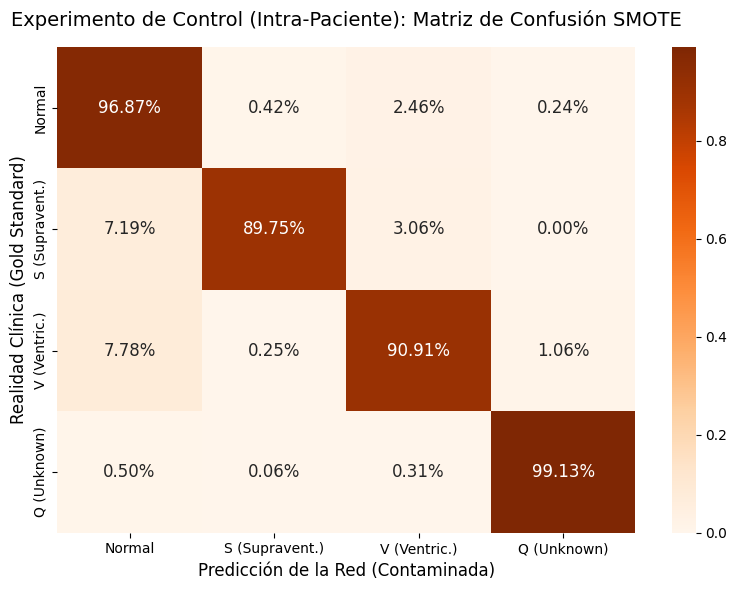


REPORTE DE CLASIFICACIÓN DEL MODELO ESPEJO (4 CATEGORÍAS AAMI)
                precision    recall  f1-score   support

        Normal     0.9902    0.9687    0.9794     18095
S (Supravent.)     0.8603    0.8975    0.8785       556
  V (Ventric.)     0.7573    0.9091    0.8263      1606
   Q (Unknown)     0.9631    0.9913    0.9770      1606

      accuracy                         0.9642     21863
     macro avg     0.8927    0.9416    0.9153     21863
  weighted avg     0.9678    0.9642    0.9654     21863


F1-Score Macro Global Falso: 0.9153


In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tensorflow.keras.models import load_model

print("Cargando el modelo del experimento fraudulento...")
model_path_fake = "../models/classificator_v1_fake_SMOTE_RUS.keras"

# Al usar CategoricalCrossentropy, la carga es directa sin custom_objects
model_eval_fake = load_model(model_path_fake)

print("Realizando predicciones sobre el set de test mezclado (Intra-Paciente)...")
y_pred_fake_raw = model_eval_fake.predict([X_test_sig_intra, X_test_rr_final_norm_intra])

y_pred_fake = np.argmax(y_pred_fake_raw, axis=-1)
y_true_fake = y_test_intra  # Ya viene en etiquetas de enteros (0, 1, 2, 3)

labels_m2 = [0, 1, 2, 3]
classes_m2_names = ['Normal', 'S (Supravent.)', 'V (Ventric.)', 'Q (Unknown)']

# ==========================================
# MATRIZ DE CONFUSIÓN INTRA-PACIENTE NORMALIZADA
# ==========================================
cm = confusion_matrix(y_true_fake, y_pred_fake, labels=labels_m2, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.2%', 
    cmap='Oranges', # Cambiamos a naranja para diferenciar visualmente este experimento en tu TFG
    xticklabels=classes_m2_names, 
    yticklabels=classes_m2_names,
    annot_kws={"size": 12}
)
plt.title('Experimento de Control (Intra-Paciente): Matriz de Confusión SMOTE', fontsize=14, pad=15)
plt.ylabel('Realidad Clínica (Gold Standard)', fontsize=12)
plt.xlabel('Predicción de la Red (Contaminada)', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# REPORTE DE RENDIMIENTO FRAUDULENTO
# ==========================================
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN DEL MODELO ESPEJO (4 CATEGORÍAS AAMI)")
print("="*60)
print(classification_report(y_true_fake, y_pred_fake, labels=labels_m2, target_names=classes_m2_names, digits=4))

macro_f1_fake = f1_score(y_true_fake, y_pred_fake, labels=labels_m2, average='macro')
print(f"\nF1-Score Macro Global Falso: {macro_f1_fake:.4f}")